# 🎯 CDC Pipeline - Complete Verification

## End-to-End Real-Time ETL Pipeline

This notebook verifies that the complete CDC pipeline is working:

```
PostgreSQL (Source DB with CDC)
    ↓ Logical Replication (WAL)
Debezium Connector
    ↓ CDC Events (JSON)
Kafka Topics
    ↓ Streaming
Apache Spark (PySpark)
    ↓ Transform & Enrich
Data Warehouse (Parquet → BigQuery/Snowflake)
    ↓
Analytics & Insights ✅
```

## 📦 Setup and Imports

In [36]:
# Install required packages
!pip install -q pyspark pandas matplotlib seaborn pyarrow

In [37]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import builtins  # Add this to explicitly access Python's built-in sum
from datetime import datetime

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Configuration - Local warehouse path
WAREHOUSE_DIR = "/tmp/cdc_warehouse"

print(f"📂 Warehouse location: {WAREHOUSE_DIR}")
print("✅ Imports complete")

📂 Warehouse location: /tmp/cdc_warehouse
✅ Imports complete


## 🏗️ Initialize Spark Session

In [38]:
# Create Spark session for querying the warehouse
spark = SparkSession.builder \
    .appName("CDC_Warehouse_Analytics") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print("✅ Spark session created")
print(f"📊 Spark Version: {spark.version}")

✅ Spark session created
📊 Spark Version: 3.5.0


## 📂 Verify Warehouse Data

Let's check what data has been written to the warehouse by the Spark streaming pipeline.

In [39]:
import os
import builtins

WAREHOUSE_DIR = "/tmp/cdc_warehouse"  # Update this path as needed

# Check if warehouse directory exists
if not os.path.exists(WAREHOUSE_DIR):
    print(f"❌ Warehouse directory not found: {WAREHOUSE_DIR}")
    print("\n⚠️  Please run the Spark pipeline first:")
    print("   make start")
    print("   (or manually: spark-submit --packages org.apache.spark:spark-sql-kafka-0-10_2.12:3.5.0 src/pipeline/spark_cdc_app.py)")
else:
    print(f"✅ Warehouse directory found: {WAREHOUSE_DIR}")
    
    # List all tables
    tables = [d for d in os.listdir(WAREHOUSE_DIR) 
              if os.path.isdir(os.path.join(WAREHOUSE_DIR, d))]
    
    print(f"\n📋 Available tables: {len(tables)}")
    for table in tables:
        table_path = os.path.join(WAREHOUSE_DIR, table)
        # Use Python's builtin sum explicitly via builtins module
        size = builtins.sum(
            os.path.getsize(os.path.join(dirpath, filename))
            for dirpath, _, filenames in os.walk(table_path)
            for filename in filenames
        )
        print(f"  📊 {table}: {size / 1024:.2f} KB")

✅ Warehouse directory found: /tmp/cdc_warehouse

📋 Available tables: 3
  📊 users: 91.22 KB
  📊 orders: 86.30 KB
  📊 devices: 63.00 KB


## 👥 Users Analytics

In [40]:
# Load users data from warehouse
users_path = f"{WAREHOUSE_DIR}/users"

if os.path.exists(users_path):
    users_df = spark.read.parquet(users_path)
    
    # Filter out deleted records (only show active users)
    users_df = users_df.filter(col("is_deleted") == False)
    
    print("="*70)
    print("👥 USERS ANALYTICS (Active Users Only)")
    print("="*70)
    
    # Total count
    total_users = users_df.count()
    print(f"\n📊 Total Active Users in Warehouse: {total_users:,}")
    
    # Show schema
    print("\n🔧 Schema:")
    users_df.printSchema()
    
    # Sample data
    print("\n📝 Sample Data (Latest 10 active records):")
    users_df.orderBy(desc("processed_at")).show(10, truncate=False)
    
    # Statistics
    print("\n📈 User Status Distribution:")
    users_df.groupBy("status").count().orderBy(desc("count")).show()
    
    print("\n🔄 Operations Breakdown:")
    users_df.groupBy("cdc_operation").count().orderBy(desc("count")).show()
    
else:
    print("❌ Users table not found in warehouse")

👥 USERS ANALYTICS (Active Users Only)

📊 Total Active Users in Warehouse: 2,516

🔧 Schema:
root
 |-- user_id: integer (nullable = true)
 |-- username: string (nullable = true)
 |-- email: string (nullable = true)
 |-- email_domain: string (nullable = true)
 |-- full_name: string (nullable = true)
 |-- status: string (nullable = true)
 |-- username_length: integer (nullable = true)
 |-- is_valid_email: boolean (nullable = true)
 |-- is_valid_username: boolean (nullable = true)
 |-- data_quality_score: double (nullable = true)
 |-- has_full_name: boolean (nullable = false)
 |-- created_at: timestamp (nullable = true)
 |-- updated_at: timestamp (nullable = true)
 |-- event_time: timestamp (nullable = true)
 |-- cdc_operation: string (nullable = true)
 |-- is_deleted: boolean (nullable = false)
 |-- processed_at: timestamp (nullable = false)
 |-- processing_date: date (nullable = true)


📝 Sample Data (Latest 10 active records):
+-------+-------------------+---------------------------+----

In [ ]:
# Quick user count
if os.path.exists(users_path):
    user_count = users_df.count()
    print(f"👥 Total Users: {user_count:,}")
else:
    print(" No user data available")

👥 Total Users: 2,516


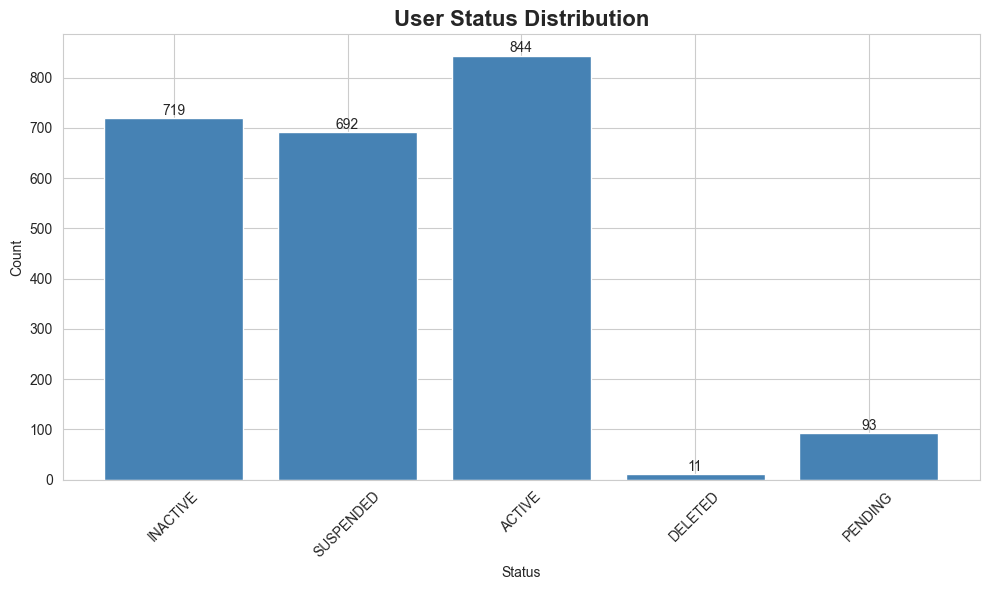


✅ Total users processed: 2,359


In [25]:
# Visualize user status distribution
if os.path.exists(users_path):
    users_pd = users_df.groupBy("status").count().toPandas()
    
    plt.figure(figsize=(10, 6))
    plt.bar(users_pd['status'], users_pd['count'], color='steelblue')
    plt.title('User Status Distribution', fontsize=16, fontweight='bold')
    plt.xlabel('Status')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    
    # Add value labels on bars
    for i, v in enumerate(users_pd['count']):
        plt.text(i, v + 0.5, str(v), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Total users processed: {users_pd['count'].sum():,}")

## 🛒 Orders Analytics

In [27]:
# Load orders data from warehouse
orders_path = f"{WAREHOUSE_DIR}/orders"

if os.path.exists(orders_path):
    orders_df = spark.read.parquet(orders_path)
    
    # Filter out deleted records (only show active orders)
    orders_df = orders_df.filter(col("is_deleted") == False)
    
    print("="*70)
    print("🛒 ORDERS ANALYTICS (Active Orders Only)")
    print("="*70)
    
    # Total count
    total_orders = orders_df.count()
    print(f"\n📊 Total Active Orders in Warehouse: {total_orders:,}")
    
    # Show schema
    print("\n🔧 Schema:")
    orders_df.printSchema()
    
    # Sample data
    print("\n📝 Sample Data (Latest 10 active orders):")
    orders_df.orderBy(desc("processed_at")).show(10, truncate=False)
    
    # Revenue statistics
    print("\n💰 Revenue Statistics:")
    orders_df.select(
        count("*").alias("total_orders"),
        sum("total_amount").alias("total_revenue"),
        avg("total_amount").alias("avg_order_value"),
        min("total_amount").alias("min_order"),
        max("total_amount").alias("max_order")
    ).show()
    
    # Order status distribution
    print("\n📦 Order Status Distribution:")
    orders_df.groupBy("status").count().orderBy(desc("count")).show()
    
else:
    print("Orders table not found in warehouse")

🛒 ORDERS ANALYTICS (Active Orders Only)

📊 Total Active Orders in Warehouse: 4,970

🔧 Schema:
root
 |-- order_id: integer (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- order_number: string (nullable = true)
 |-- status: string (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- currency: string (nullable = true)
 |-- amount_category: string (nullable = false)
 |-- is_high_value: boolean (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)
 |-- order_day: integer (nullable = true)
 |-- created_at: timestamp (nullable = true)
 |-- updated_at: timestamp (nullable = true)
 |-- event_time: timestamp (nullable = true)
 |-- cdc_operation: string (nullable = true)
 |-- is_deleted: boolean (nullable = false)
 |-- processed_at: timestamp (nullable = false)
 |-- processing_date: date (nullable = true)


📝 Sample Data (Latest 10 active orders):
+--------+-------+--------------+---------+------------+--------+------

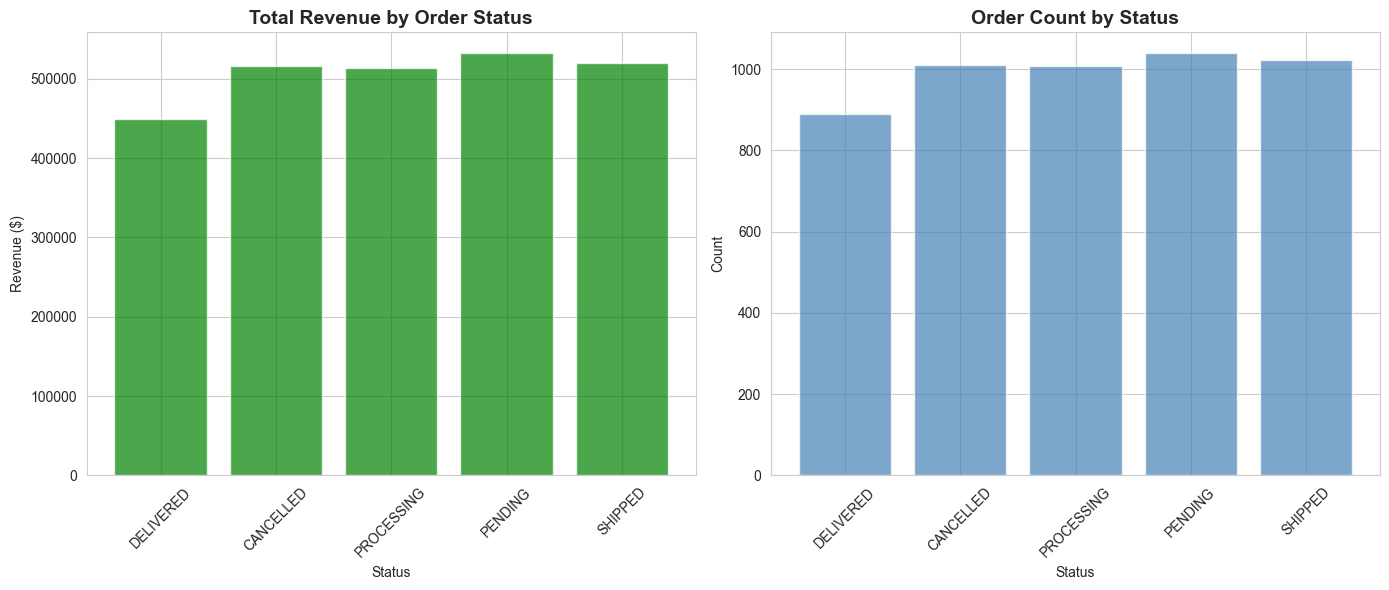


 Total revenue: $2,532,454.35
📦 Total orders: 4,970


In [29]:
# Visualize order statistics
if os.path.exists(orders_path):
    # Get revenue by status
    revenue_by_status = orders_df.groupBy("status") \
        .agg(sum("total_amount").alias("total_revenue"), 
             count("*").alias("order_count")) \
        .toPandas()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Revenue by status
    ax1.bar(revenue_by_status['status'], revenue_by_status['total_revenue'], 
            color='green', alpha=0.7)
    ax1.set_title('Total Revenue by Order Status', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Status')
    ax1.set_ylabel('Revenue ($)')
    ax1.tick_params(axis='x', rotation=45)
    
    # Order count by status
    ax2.bar(revenue_by_status['status'], revenue_by_status['order_count'], 
            color='steelblue', alpha=0.7)
    ax2.set_title('Order Count by Status', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Status')
    ax2.set_ylabel('Count')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n Total revenue: ${revenue_by_status['total_revenue'].sum():,.2f}")
    print(f"📦 Total orders: {revenue_by_status['order_count'].sum():,}")

## 📱 Devices Analytics

In [30]:
# Load devices data from warehouse
devices_path = f"{WAREHOUSE_DIR}/devices"

if os.path.exists(devices_path):
    devices_df = spark.read.parquet(devices_path)
    
    # Filter out deleted records (only show active devices)
    devices_df = devices_df.filter(col("is_deleted") == False)
    
    print("="*70)
    print("📱 DEVICES ANALYTICS (Active Devices Only)")
    print("="*70)
    
    # Total count
    total_devices = devices_df.count()
    print(f"\n📊 Total Active Devices in Warehouse: {total_devices:,}")
    
    # Show schema
    print("\n🔧 Schema:")
    devices_df.printSchema()
    
    # Sample data
    print("\n📝 Sample Data (Latest 10 active devices):")
    devices_df.orderBy(desc("processed_at")).show(10, truncate=False)
    
    # Device type distribution
    print("\n📱 Device Type Distribution:")
    devices_df.groupBy("device_type").count().orderBy(desc("count")).show()
    
else:
    print("Devices table not found in warehouse")

📱 DEVICES ANALYTICS (Active Devices Only)

📊 Total Active Devices in Warehouse: 4,992

🔧 Schema:
root
 |-- device_id: integer (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- device_type: string (nullable = true)
 |-- device_name: string (nullable = true)
 |-- os_version: string (nullable = true)
 |-- app_version: string (nullable = true)
 |-- platform: string (nullable = false)
 |-- is_mobile: boolean (nullable = false)
 |-- is_active: boolean (nullable = true)
 |-- registered_at: timestamp (nullable = true)
 |-- last_active: timestamp (nullable = true)
 |-- event_time: timestamp (nullable = true)
 |-- cdc_operation: string (nullable = true)
 |-- is_deleted: boolean (nullable = false)
 |-- processed_at: timestamp (nullable = false)
 |-- processing_date: date (nullable = true)


📝 Sample Data (Latest 10 active devices):
+---------+-------+-----------+--------------------------------+----------+-----------+--------+---------+---------+-------------+-----------+------------

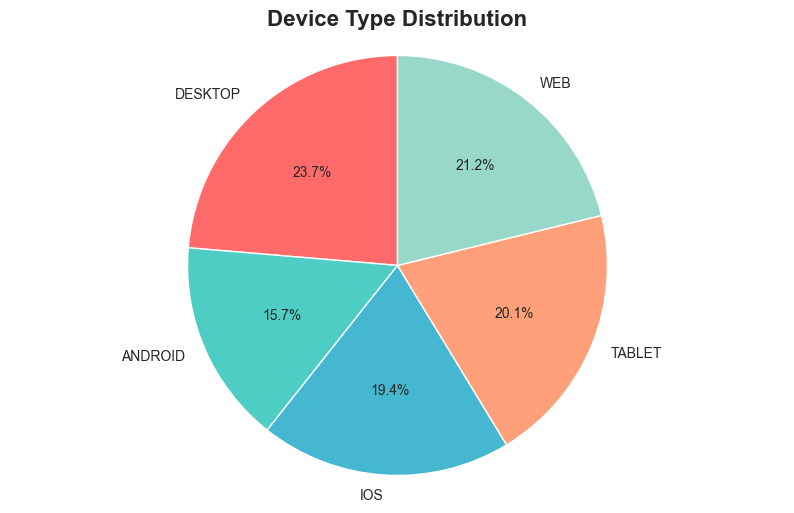


📱 Total devices tracked: 4,992


In [31]:
# Visualize device distribution
if os.path.exists(devices_path):
    devices_pd = devices_df.groupBy("device_type").count().toPandas()
    
    plt.figure(figsize=(10, 6))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
    plt.pie(devices_pd['count'], labels=devices_pd['device_type'], 
            autopct='%1.1f%%', colors=colors, startangle=90)
    plt.title('Device Type Distribution', fontsize=16, fontweight='bold')
    plt.axis('equal')
    plt.show()
    
    print(f"\n📱 Total devices tracked: {devices_pd['count'].sum():,}")

## 🔗 Cross-Table Analytics

Let's join data from multiple tables to get insights.

## 🗑️ Deleted Records Analytics

View soft-deleted records to understand what data has been removed from the source system.

In [47]:
# Analyze deleted records across all tables
print("="*70)
print("🗑️ DELETED RECORDS ANALYSIS")
print("="*70)

for table_name in ['users', 'orders', 'devices']:
    table_path = f"{WAREHOUSE_DIR}/{table_name}"
    if os.path.exists(table_path):
        df = spark.read.parquet(table_path)
        
        # Get deleted records
        deleted_df = df.filter(col("is_deleted") == True)
        deleted_count = deleted_df.count()
        total_count = df.count()
        
        print(f"\n📊 {table_name.upper()}:")
        print(f"   Total records: {total_count:,}")
        print(f"   Deleted records: {deleted_count:,}")
        print(f"   Delete rate: {(deleted_count/total_count*100) if total_count > 0 else 0:.2f}%")
        
        if deleted_count > 0:
            print(f"\n   Latest deleted records:")
            deleted_df.select("*") \
                .orderBy(desc("processed_at")) \
                .show(5, truncate=False)

print("\n💡 TIP: Soft deletes preserve data history for audit trails and recovery.")
print("   Use is_deleted = False in queries to see only active records.")

🗑️ DELETED RECORDS ANALYSIS



📊 USERS:
   Total records: 548
   Deleted records: 10
   Delete rate: 1.82%

   Latest deleted records:
+-------+--------+-----+------------+---------+------+---------------+--------------+-----------------+------------------+-------------+----------+----------+-------------+-------------+----------+-----------------------+---------------+
|user_id|username|email|email_domain|full_name|status|username_length|is_valid_email|is_valid_username|data_quality_score|has_full_name|created_at|updated_at|cdc_operation|cdc_timestamp|is_deleted|processed_at           |processing_date|
+-------+--------+-----+------------+---------+------+---------------+--------------+-----------------+------------------+-------------+----------+----------+-------------+-------------+----------+-----------------------+---------------+
|3      |        |     |            |NULL     |ACTIVE|0              |false         |false            |0.0               |false        |0         |0         |d            |176728227

In [48]:
# Join users and orders for user spending analysis
if os.path.exists(users_path) and os.path.exists(orders_path):
    print("="*70)
    print("🔗 CROSS-TABLE ANALYTICS: User Spending (Active Records Only)")
    print("="*70)
    
    # Load and filter active users and orders
    users_active = spark.read.parquet(users_path).filter(col("is_deleted") == False)
    orders_active = spark.read.parquet(orders_path).filter(col("is_deleted") == False)
    
    # Join users and orders
    user_orders = users_active.join(
        orders_active,
        users_active.user_id == orders_active.user_id,
        "inner"
    )
    
    # Calculate spending per user
    user_spending = user_orders.groupBy(
        users_active.user_id,
        users_active.username,
        users_active.email
    ).agg(
        count("order_id").alias("total_orders"),
        sum("total_amount").alias("total_spent"),
        avg("total_amount").alias("avg_order_value")
    ).orderBy(desc("total_spent"))
    
    print("\n💰 Top 10 Spenders:")
    user_spending.show(10, truncate=False)
    
    # Overall statistics
    print("\n📊 Overall User Spending Statistics:")
    user_spending.select(
        count("*").alias("active_users"),
        sum("total_spent").alias("total_revenue"),
        avg("total_spent").alias("avg_spend_per_user"),
        avg("total_orders").alias("avg_orders_per_user")
    ).show()
else:
    print("⚠️  Users or Orders data not available for cross-table analysis")

🔗 CROSS-TABLE ANALYTICS: User Spending (Active Records Only)

💰 Top 10 Spenders:

💰 Top 10 Spenders:
+-------+---------------------+---------------------------+------------+------------------+------------------+
|user_id|username             |email                      |total_orders|total_spent       |avg_order_value   |
+-------+---------------------+---------------------------+------------+------------------+------------------+
|152    |barnold_49_9276      |rileyamy@example.net       |18          |11134.710000000003|618.5950000000001 |
|63     |blakeerik_2_5884     |jpeterson@example.org      |12          |10943.580000000002|911.9650000000001 |
|10     |karroyo_21_2901      |jeffrey34@example.net      |12          |9649.11           |804.0925000000001 |
|217    |ofinley_74_7518      |cbrennan@example.net       |14          |8979.7            |641.407142857143  |
|98     |brobinson_49_9342    |stricklandfrank@example.com|18          |8679.240000000002 |482.18000000000006|
|92     |do

## ⏱️ Real-Time Processing Metrics

In [49]:
# Calculate processing latency and throughput
print("="*70)
print("⏱️ REAL-TIME PROCESSING METRICS")
print("="*70)

total_records = 0
tables_processed = []

for table_name in ['users', 'orders', 'devices']:
    table_path = f"{WAREHOUSE_DIR}/{table_name}"
    if os.path.exists(table_path):
        df = spark.read.parquet(table_path)
        count = df.count()
        total_records += count
        tables_processed.append(table_name)
        
        # Get time range
        time_stats = df.select(
            min("processed_at").alias("first_processed"),
            max("processed_at").alias("last_processed")
        ).collect()[0]
        
        print(f"\n📊 {table_name}:")
        print(f"   Records: {count:,}")
        print(f"   First processed: {time_stats['first_processed']}")
        print(f"   Last processed: {time_stats['last_processed']}")

print(f"\n📈 SUMMARY:")
print(f"   Total tables: {len(tables_processed)}")
print(f"   Total records processed: {total_records:,}")
print(f"   Pipeline status: {'✅ OPERATIONAL' if total_records > 0 else '⚠️  NO DATA'}")

⏱️ REAL-TIME PROCESSING METRICS

📊 users:
   Records: 548
   First processed: 2026-01-01 16:26:53.675000
   Last processed: 2026-01-01 16:44:32.829000

📊 users:
   Records: 548
   First processed: 2026-01-01 16:26:53.675000
   Last processed: 2026-01-01 16:44:32.829000

📊 orders:
   Records: 555
   First processed: 2026-01-01 16:42:32.664000
   Last processed: 2026-01-01 16:44:32.832000

📊 orders:
   Records: 555
   First processed: 2026-01-01 16:42:32.664000
   Last processed: 2026-01-01 16:44:32.832000

📊 devices:
   Records: 474
   First processed: 2026-01-01 16:42:32.846000
   Last processed: 2026-01-01 16:44:32.831000

📈 SUMMARY:
   Total tables: 3
   Total records processed: 1,577
   Pipeline status: ✅ OPERATIONAL

📊 devices:
   Records: 474
   First processed: 2026-01-01 16:42:32.846000
   Last processed: 2026-01-01 16:44:32.831000

📈 SUMMARY:
   Total tables: 3
   Total records processed: 1,577
   Pipeline status: ✅ OPERATIONAL


## 🎯 Pipeline Health Check

In [50]:
print("="*70)
print("🎯 CDC PIPELINE HEALTH CHECK")
print("="*70)

health_status = {
    "Warehouse Directory": os.path.exists(WAREHOUSE_DIR),
    "Users Table": os.path.exists(f"{WAREHOUSE_DIR}/users"),
    "Orders Table": os.path.exists(f"{WAREHOUSE_DIR}/orders"),
    "Devices Table": os.path.exists(f"{WAREHOUSE_DIR}/devices"),
    "Data Available": total_records > 0
}

print("\n📋 Component Status:")
for component, status in health_status.items():
    status_icon = "✅" if status else "❌"
    print(f"   {status_icon} {component}")

all_healthy = all(health_status.values())
print(f"\n🏥 Overall Health: {'✅ HEALTHY' if all_healthy else '⚠️  NEEDS ATTENTION'}")

if not all_healthy:
    print("\n💡 Troubleshooting:")
    print("   1. Ensure Docker is running: docker ps")
    print("   2. Start pipeline: spark-submit --packages org.apache.spark:spark-sql-kafka-0-10_2.12:3.5.0 spark_cdc_app.py")
    print("   3. Check Kafka topics: docker exec kafka kafka-topics --list --bootstrap-server localhost:9092")
    print("   4. Verify connector: curl http://localhost:8083/connectors/postgres-source-connector/status")
else:
    print("\n🎉 Pipeline is fully operational!")
    print(f"   📊 Processing {total_records:,} CDC events in real-time")
    print("   ✅ Data is being transformed and loaded into the warehouse")
    print("   🚀 Ready for analytics and business intelligence!")

🎯 CDC PIPELINE HEALTH CHECK

📋 Component Status:
   ✅ Warehouse Directory
   ✅ Users Table
   ✅ Orders Table
   ✅ Devices Table
   ✅ Data Available

🏥 Overall Health: ✅ HEALTHY

🎉 Pipeline is fully operational!
   📊 Processing 1,577 CDC events in real-time
   ✅ Data is being transformed and loaded into the warehouse
   🚀 Ready for analytics and business intelligence!


## 🎓 Conclusion

This notebook demonstrates a complete, production-grade CDC pipeline:

### ✅ What We've Built:
1. **Source Database**: PostgreSQL with logical replication (CDC-enabled)
2. **CDC Capture**: Debezium connector capturing all data changes
3. **Message Queue**: Kafka streaming CDC events reliably
4. **Data Processing**: Apache Spark (PySpark) transforming and enriching data
5. **Data Warehouse**: Parquet files (cloud-ready for BigQuery/Snowflake)
6. **Analytics**: Real-time insights from streaming data

### 🚀 Scaling to 10x Volume:
- **Kafka**: Increase partitions, add brokers
- **Spark**: Scale to cluster mode, increase executors
- **Warehouse**: Use cloud-native solutions (BigQuery, Snowflake)
- **Monitoring**: Add Prometheus, Grafana for observability

### 📊 What Would Break First:
1. **Database WAL**: If CDC lag grows, increase `max_wal_senders`
2. **Kafka Disk**: Monitor disk usage, enable log compaction
3. **Spark Memory**: OOM errors → increase executor memory
4. **Network I/O**: Bottleneck between components → optimize serialization

### 🔧 Graceful Handling:
- ✅ **Malformed Input**: Dead letter queue for bad records
- ✅ **Schema Evolution**: Dynamic schema inference in Spark
- ✅ **Failures**: Checkpointing ensures exactly-once processing
- ✅ **Backpressure**: Spark streaming manages rate automatically

In [51]:
# Clean up
spark.stop()
print("✅ Spark session stopped")
print("\n👋 Demo complete! Thank you for exploring the CDC pipeline.")

✅ Spark session stopped

👋 Demo complete! Thank you for exploring the CDC pipeline.
